## REAL OPTIONS — SELLPERP
# **YEAR 1: WHEN TO SELL ACCUMULATED COPPER/ALUMINIUM RECYCLING OUTPUT**

Every month, recycling produces a fixed quantity of copper and aluminium.
At each month-end, the holder decides whether to sell EVERYTHING
accumulated so far, or keep it in storage and let it grow. Storage has a
capacity limit — once holding through another month's production would
exceed it, that month's excess production must be sold regardless of price
(the older, already-capped pile itself is untouched). The question this
script answers:

**How much is this selling-timing flexibility worth, compared to (a)
selling every month's output immediately with no storage at all, (b) always
waiting until storage is full and then liquidating everything, and (c)
selling at randomly chosen (not price-driven) intervals?**

Structurally this is a repeated, resetting version of the single-decision
lattice in `results/buyperp/year1_purchase_option.py`: a sale can happen
several times within the year (accumulation restarts from zero after each
one), so the underlying state needs an extra dimension — months of
unsold accumulation — on top of the price lattice. The reusable pricing
logic lives in `src/real_options/swing_sell.py` (tested in
`tests/test_swing_sell.py`), which itself reuses several building blocks
from `src/real_options/bermudan_purchase.py` (the binomial tree
construction, volatility/drift estimation, GBM path simulation) rather than
duplicating them.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.real_options import bermudan_purchase as bp
from src.real_options import swing_sell as ss

### Configuration

Business quantities and toggle switches live here, at the top of the file.

In [2]:
# --- Business quantities (monthly recycling output + storage limits) --------
CU_QTY_MONTHLY = 10.0  # copper produced per month, tonnes
AL_QTY_MONTHLY = 10.0  # aluminium produced per month, tonnes
LAGER_CU = 100.0  # copper storage capacity, tonnes
LAGER_AL = 100.0  # aluminium storage capacity, tonnes
N_MONTHS = 12  # decision points this year (monthly month-end), Jan-Dec
YEAR_1_MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]  # fmt: skip

# How much trailing history feeds sigma/mu (see bermudan_purchase.py / the
# buyperp result for why real-world drift, not risk-neutral, is used). Ceiling
# is 3 — how far back results/sellperp/metals_prices.csv currently reaches.
VOLATILITY_LOOKBACK_YEARS = 1

# --- Toggle switches for the optional verification procedures ---------------
INCLUDE_MC_VERIFICATION_ANCHORS = True  # re-derive baselines A & B via simulation
INCLUDE_RANDOM_CYCLE_BASELINE = True  # baseline C: repeated random holding periods

N_SIMULATIONS = 10_000
MONTE_CARLO_SEED = 42

### Load the input data

Both files were produced by `src/data_collection/pipeline.py` (run via
`python main.py` from the project root) and copied into this folder
specifically so this script needs no path configuration at all.

In [3]:
metals = pd.read_csv("metals_prices.csv", parse_dates=["date"])
sofr = pd.read_csv("sofr_rate.csv", parse_dates=["date"])

metals.tail(3)

,date,cu_usd_per_tonne,al_usd_per_tonne,eur_usd_rate,cu_eur_per_tonne,al_eur_per_tonne
754,2026-06-30,13341.0,3105.5,1.1394,11708.794102,2725.557311
755,2026-07-01,13170.0,3075.0,1.1383,11569.884916,2701.396820
756,2026-07-02,13202.0,3061.5,1.1399,11581.717695,2685.761909


### Storage capacity in months, and the "batch value" series

Since production is constant, storage capacity translates directly into a
maximum number of months of accumulation (`max_cycle`) — at the current
quantities/capacities, 10 months' worth fits before capacity binds.

The decision only ever cares about the value of ONE MONTH's worth of
production, since the accumulated pile (however many months' worth) is
fungible and sells at today's price regardless of when each part of it was
produced. So — mirroring the "basket cost" trick in `bermudan_purchase.py`
— we build a single "batch value" series and estimate sigma/mu directly
from its own historical returns over the trailing `VOLATILITY_LOOKBACK_YEARS`
window (not the full history — see the Configuration cell). `v0`/`fx0`
themselves always use the single latest observation.

In [4]:
max_cycle = int(min(LAGER_CU // CU_QTY_MONTHLY, LAGER_AL // AL_QTY_MONTHLY))

metals["batch_value_usd"] = (
    CU_QTY_MONTHLY * metals["cu_usd_per_tonne"] + AL_QTY_MONTHLY * metals["al_usd_per_tonne"]
)

lookback_cutoff = metals["date"].max() - pd.DateOffset(years=VOLATILITY_LOOKBACK_YEARS)
recent_metals = metals[metals["date"] >= lookback_cutoff]
assert not recent_metals.empty, "VOLATILITY_LOOKBACK_YEARS exceeds the data actually available"

sigma = bp.annualized_volatility(recent_metals["batch_value_usd"])
mu = bp.annualized_drift(recent_metals["batch_value_usd"])
v0_usd = float(metals["batch_value_usd"].iloc[-1])

fx_sigma = bp.annualized_volatility(recent_metals["eur_usd_rate"])
fx_mu = bp.annualized_drift(recent_metals["eur_usd_rate"])
fx0 = float(metals["eur_usd_rate"].iloc[-1])

r = float(sofr["sofr_rate_pct"].iloc[-1]) / 100.0
dt = 1.0 / N_MONTHS

print(f"Storage capacity, in months (max_cycle):  {max_cycle:>8}")
print(f"v0 (today's one-month batch value):       {v0_usd:>12,.0f} USD")
print(f"Annualized volatility sigma:               {sigma:>12.1%}")
print(f"Annualized real-world drift mu:            {mu:>12.1%}  (trailing {VOLATILITY_LOOKBACK_YEARS}y)")
print(f"Risk-free discount rate r (SOFR):          {r:>12.2%}")
print(f"EUR/USD rate now (fx0):                    {fx0:>12.4f}")

Storage capacity, in months (max_cycle):        10
v0 (today's one-month batch value):            162,635 USD
Annualized volatility sigma:                      19.5%
Annualized real-world drift mu:                   25.2%  (trailing 1y)
Risk-free discount rate r (SOFR):                 3.66%
EUR/USD rate now (fx0):                          1.1399


### Why real-world drift, and why the risk-neutral case is trivial here too

Just like `bermudan_purchase.py`, selling a fungible commodity at its own
prevailing market price is a *linear* payoff in price, so a risk-neutral
tree (drift=r) makes selling immediately, waiting for storage to fill, and
adaptive optimal timing all worth EXACTLY the same — no timing value at
all, regardless of sigma. We use `mu` (estimated from our own collected
data) instead, for the same reason as buyperp: this is a physical,
non-hedgeable decision, not a marketable derivative.

In [5]:
risk_neutral_reference = ss.price_swing_sell_option(v0_usd, sigma, r, r, N_MONTHS, max_cycle, dt)
risk_neutral_baseline_a = ss.baseline_sell_immediately_revenue(v0_usd, r, r, N_MONTHS, dt)
print(f"Textbook risk-neutral value (drift=r): {risk_neutral_reference:>12,.0f} USD")
print(f"                   == Baseline A?      {risk_neutral_baseline_a:>12,.0f} USD")

Textbook risk-neutral value (drift=r):    1,951,620 USD
                   == Baseline A?         1,951,620 USD


### The core valuation: optimal sell timing via backward induction

`price_swing_sell_option` walks backward from December to January. At
every month, for every possible accumulated-months state, it compares
selling everything now against the discounted expected value of continuing
to accumulate — the mirror image of `bermudan_purchase.py`'s backward
induction (there: `min` over cost; here: `max` over revenue). See the
module docstring for a proven, slightly surprising fact: the resulting
"sell if price is at least this much" threshold turns out to be the SAME
regardless of how many months' worth is currently in storage.

In [6]:
real_options_revenue = ss.price_swing_sell_option(v0_usd, sigma, mu, r, N_MONTHS, max_cycle, dt)
exercise_thresholds = ss.swing_sell_exercise_thresholds(v0_usd, sigma, mu, r, N_MONTHS, max_cycle, dt)

print(f"Real-options revenue (optimal timing): {real_options_revenue:>12,.0f} USD")

Real-options revenue (optimal timing):    2,408,833 USD


### Currency conversion: at each sale's own execution date

Since a policy here can generate SEVERAL cash flows across the year (not
just one, like buyperp), each one is converted to EUR using the EUR/USD
rate simulated forward to THAT specific sale's month — not a single
snapshot rate. We simulate the batch-value price and the EUR/USD rate as
two independent GBM paths (each with its own historical sigma/mu), then
replay the lattice's own thresholds against the price paths to find, per
simulated year, exactly when sales happen and at what price/FX rate.

In [7]:
cost_paths = bp.simulate_gbm_paths(v0_usd, sigma, mu, N_MONTHS, dt, N_SIMULATIONS, seed=MONTE_CARLO_SEED)
fx_paths = bp.simulate_gbm_paths(
    fx0, fx_sigma, fx_mu, N_MONTHS, dt, N_SIMULATIONS, seed=MONTE_CARLO_SEED + 100
)

adaptive_mc = ss.simulate_swing_sell_adaptive_baseline(
    cost_paths, exercise_thresholds, r, dt, N_MONTHS, max_cycle, fx_paths=fx_paths
)
real_options_revenue_eur = adaptive_mc["mean_eur"]

print(f"Real-options revenue, MC replay (USD): {adaptive_mc['mean']:>12,.0f}")
print(f"                       closed form:   {real_options_revenue:>12,.0f} USD")
print(f"Real-options revenue, execution-date EUR: {real_options_revenue_eur:>12,.0f} EUR")
print(f"Average number of sales per year: {adaptive_mc['mean_num_sales']:.2f}")

Real-options revenue, MC replay (USD):    2,410,376
                       closed form:      2,408,833 USD
Real-options revenue, execution-date EUR:    2,188,017 EUR
Average number of sales per year: 1.00


### Baseline A — sell every month's output immediately (no storage at all)

In [8]:
baseline_immediate = ss.baseline_sell_immediately_revenue(v0_usd, mu, r, N_MONTHS, dt)
option_value_vs_immediate = real_options_revenue - baseline_immediate

print(f"Baseline A (sell immediately): {baseline_immediate:>12,.0f} USD")
print(f"Option value vs. selling immediately: {option_value_vs_immediate:>12,.0f} USD")

Baseline A (sell immediately):    2,196,743 USD
Option value vs. selling immediately:      212,089 USD


### Baseline B — wait until storage is full, then sell everything

A simpler, non-adaptive comparison policy (not the actual physical rule,
which force-sells only the excess — see the module docstring): never sell
voluntarily; once storage would be full (every `max_cycle` months), sell
the entire pile, then start accumulating again. Any partial cycle left at
year-end is marked to market. The optimal policy is **guaranteed** to be
worth at least as much as this baseline, for any drift.

In [9]:
baseline_capacity = ss.baseline_wait_for_capacity_revenue(v0_usd, mu, r, N_MONTHS, max_cycle, dt)
option_value_vs_capacity = real_options_revenue - baseline_capacity

print(f"Baseline B (wait for storage to fill): {baseline_capacity:>12,.0f} USD")
print(f"Option value vs. waiting for capacity: {option_value_vs_capacity:>12,.0f} USD")

Baseline B (wait for storage to fill):    2,348,567 USD
Option value vs. waiting for capacity:       60,266 USD


### Verification 1 (toggle: `INCLUDE_MC_VERIFICATION_ANCHORS`)

Independently re-derives Baselines A and B by simulation, and — using the
same `fx_paths` as the core result — gives their EUR figures using the
EUR/USD rate at each of their own (possibly several) execution dates.

In [10]:
if INCLUDE_MC_VERIFICATION_ANCHORS:
    mc_anchors = ss.verify_baselines_via_monte_carlo(
        cost_paths, mu, r, dt, N_MONTHS, max_cycle, fx_paths=fx_paths
    )
    baseline_immediate_eur = mc_anchors["immediate_mean_eur"]
    baseline_capacity_eur = mc_anchors["capacity_mean_eur"]

    print(f"MC Baseline A: mean={mc_anchors['immediate_mean']:,.0f}  std={mc_anchors['immediate_std']:,.2f}")
    print(f"MC Baseline B: mean={mc_anchors['capacity_mean']:,.0f}  std={mc_anchors['capacity_std']:,.2f}")
    print(f"Closed-form Baseline A: {baseline_immediate:,.0f} | Baseline B: {baseline_capacity:,.0f}")
else:
    # Fallback: without the simulation, we can't know each sale's own future
    # FX rate, so this uses today's flat rate as a labeled approximation.
    baseline_immediate_eur = baseline_immediate / fx0
    baseline_capacity_eur = baseline_capacity / fx0
    print("Skipped (toggle off) — Baseline A/B EUR use today's flat rate as an approximation")

MC Baseline A: mean=2,196,808  std=273,538.18
MC Baseline B: mean=2,346,059  std=427,132.67
Closed-form Baseline A: 2,196,743 | Baseline B: 2,348,567


### Verification 2 / Baseline C (toggle: `INCLUDE_RANDOM_CYCLE_BASELINE`)

A "no market-timing skill" baseline: repeatedly draw a random holding
period (1..max_cycle months, uniform, independent of price), sell
everything accumulated when it elapses, and repeat for the rest of the
year — the natural analogue, for a REPEATED decision, of buyperp's
"3 random dates" baseline (which only made sense for a ONE-TIME purchase).

In [11]:
if INCLUDE_RANDOM_CYCLE_BASELINE:
    baseline_random = ss.simulate_random_cycle_baseline(
        cost_paths, r, dt, N_MONTHS, max_cycle, seed=MONTE_CARLO_SEED + 1, fx_paths=fx_paths
    )
    option_value_vs_random = real_options_revenue - baseline_random["mean"]

    print(
        f"Baseline C (random holding periods): "
        f"mean={baseline_random['mean']:,.0f} USD  |  {baseline_random['mean_eur']:,.0f} EUR"
    )
    print(f"Option value vs. random-timing selling: {option_value_vs_random:,.0f} USD")
else:
    print("Skipped (INCLUDE_RANDOM_CYCLE_BASELINE = False)")

Baseline C (random holding periods): mean=2,295,372 USD  |  2,067,300 EUR
Option value vs. random-timing selling: 113,461 USD


### Summary — in USD and EUR (EUR converted at each scenario's own execution date(s))

In [12]:
summary = pd.DataFrame(
    {
        "USD": {
            "Baseline A (sell immediately)": baseline_immediate,
            "Baseline B (wait for capacity)": baseline_capacity,
            "Real-options revenue (optimal timing)": real_options_revenue,
            "Option value vs. A (sell immediately)": option_value_vs_immediate,
            "Option value vs. B (wait for capacity)": option_value_vs_capacity,
        },
        "EUR": {
            "Baseline A (sell immediately)": baseline_immediate_eur,
            "Baseline B (wait for capacity)": baseline_capacity_eur,
            "Real-options revenue (optimal timing)": real_options_revenue_eur,
            "Option value vs. A (sell immediately)": real_options_revenue_eur - baseline_immediate_eur,
            "Option value vs. B (wait for capacity)": real_options_revenue_eur - baseline_capacity_eur,
        },
    }
)
if INCLUDE_RANDOM_CYCLE_BASELINE:
    summary.loc["Baseline C (random holding periods)", ["USD", "EUR"]] = [
        baseline_random["mean"],
        baseline_random["mean_eur"],
    ]
    summary.loc["Option value vs. C (random)", ["USD", "EUR"]] = [
        option_value_vs_random,
        real_options_revenue_eur - baseline_random["mean_eur"],
    ]

summary.round(0)

,USD,EUR
Baseline A (sell immediately),2196743.0,1964762.0
Baseline B (wait for capacity),2348567.0,2120521.0
Real-options revenue (optimal timing),2408833.0,2188017.0
Option value vs. A (sell immediately),212089.0,223256.0
Option value vs. B (wait for capacity),60266.0,67496.0
Baseline C (random holding periods),2295372.0,2067300.0
Option value vs. C (random),113461.0,120717.0


### The sell threshold over the year

Since the threshold doesn't depend on how much is currently in storage
(see the module docstring), there is a single "sell if the batch value
reaches at least this much" line per month — plotting it against `v0`
shows how much of a price rally it takes to trigger an early sale.

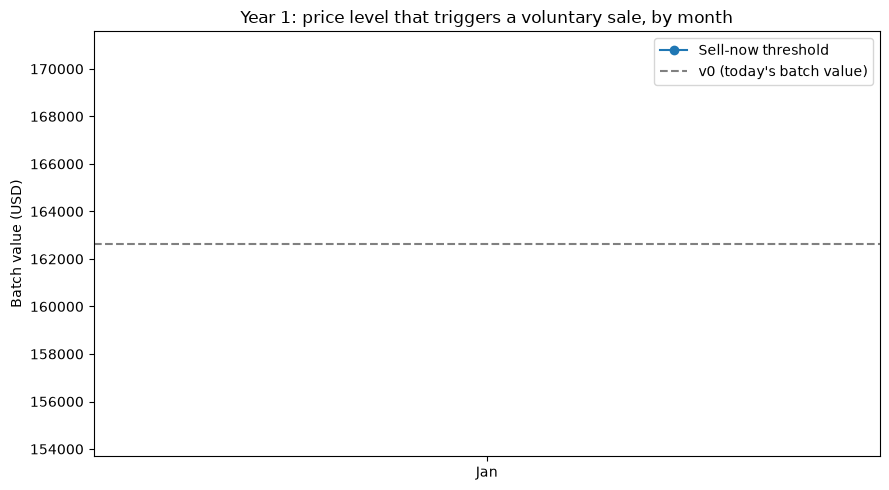

In [13]:
threshold_by_month = [exercise_thresholds[(t, 1)] for t in range(1, N_MONTHS)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(YEAR_1_MONTH_LABELS[:-1], threshold_by_month, marker="o", label="Sell-now threshold")
ax.axhline(v0_usd, color="grey", linestyle="--", label="v0 (today's batch value)")
ax.set_ylabel("Batch value (USD)")
ax.set_title("Year 1: price level that triggers a voluntary sale, by month")
ax.legend()
fig.tight_layout()